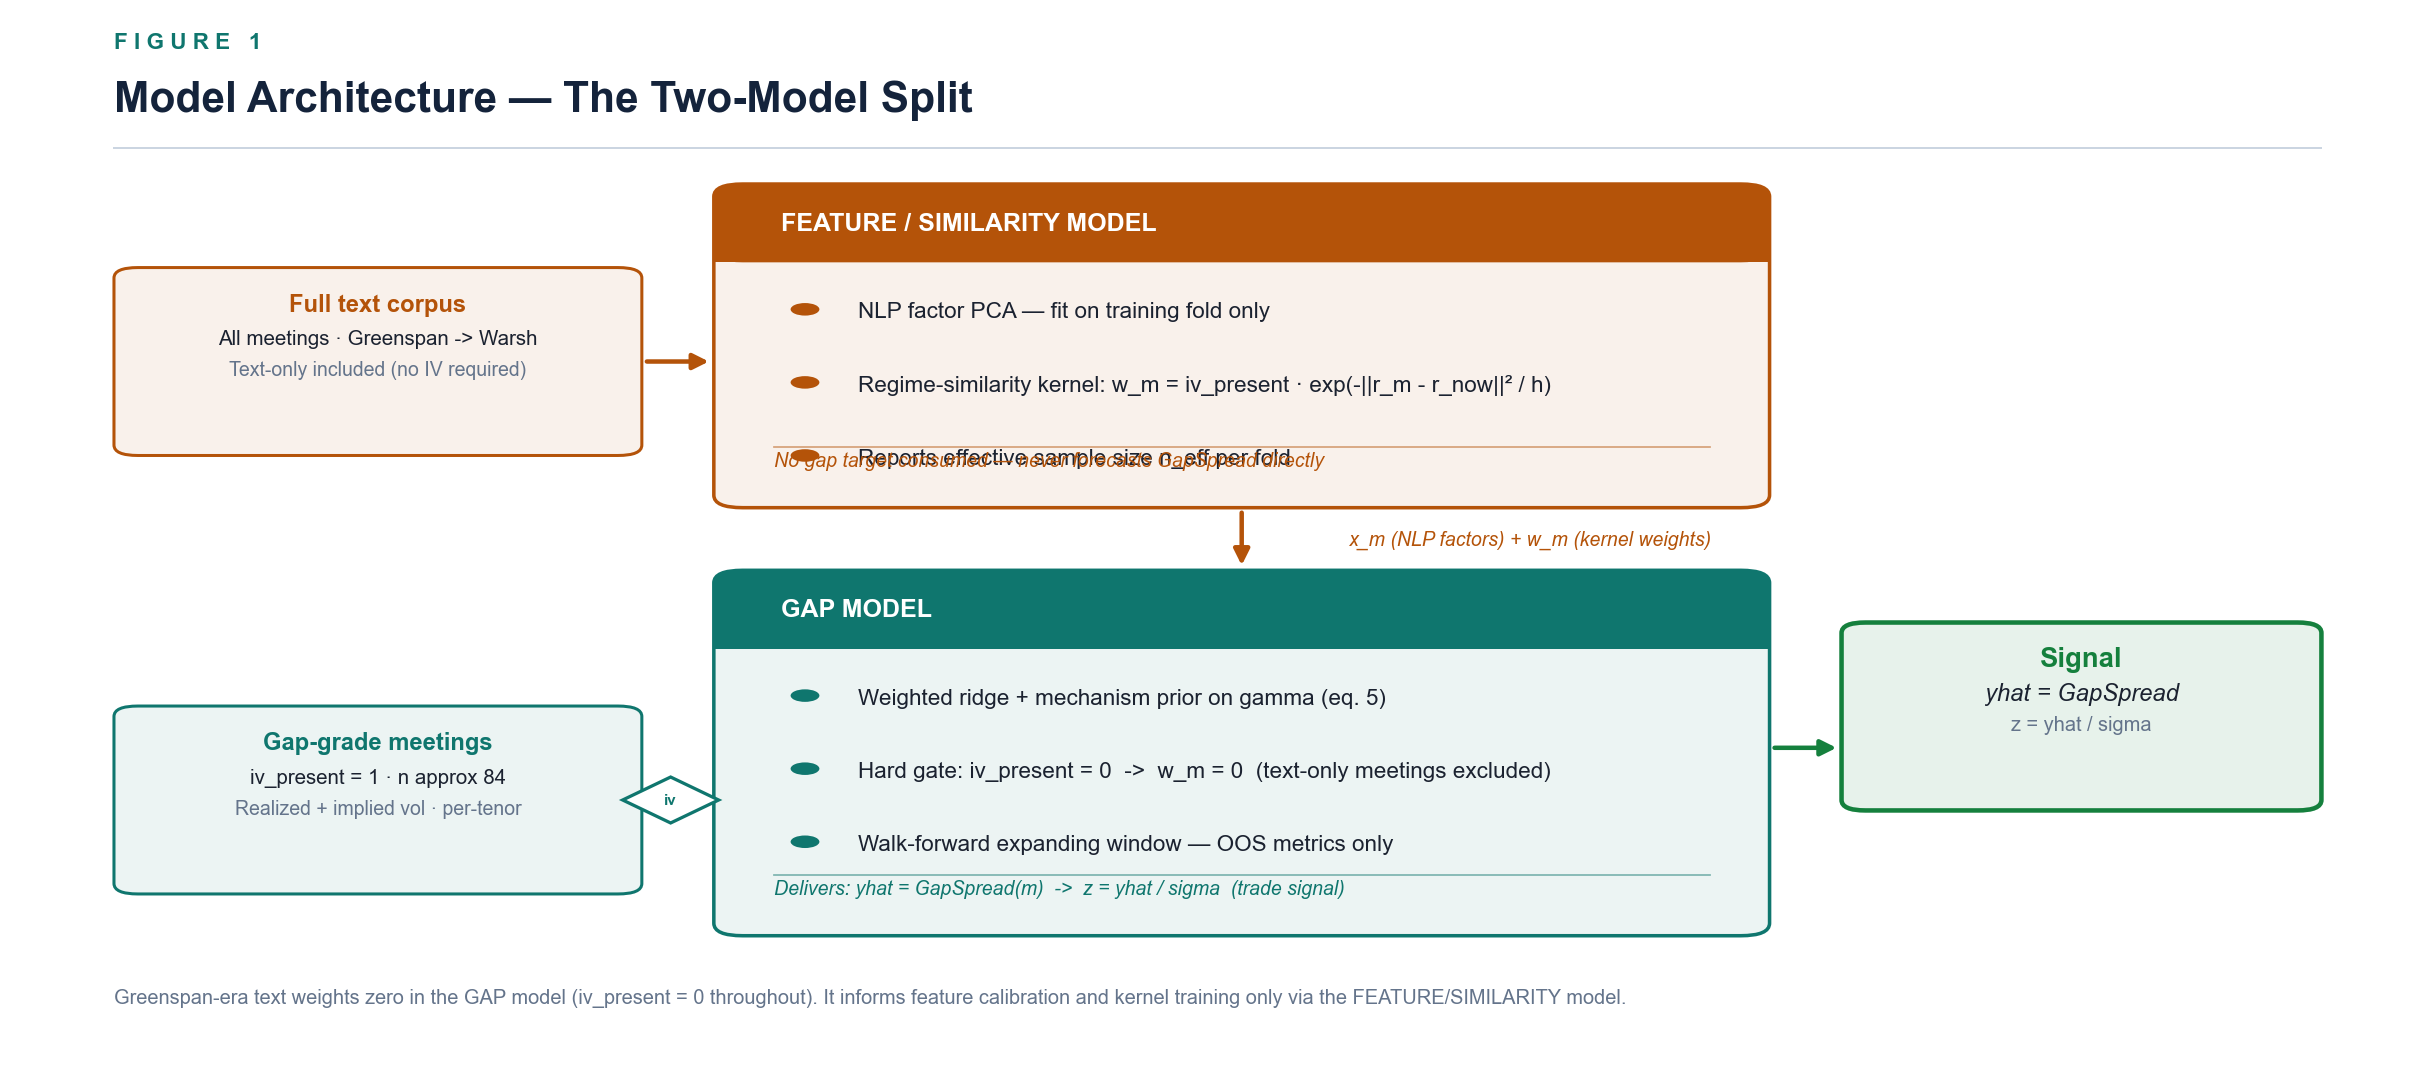

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Circle, Polygon

INK   = "#14233B"; TEAL  = "#0F766E"; AMBER = "#B45309"
PAPER = "#FFFFFF"; TX    = "#1B2230"; MUTE  = "#64748B"; FAINT = "#CBD5E1"

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica Neue", "Helvetica", "DejaVu Sans"],
})

fig = plt.figure(figsize=(13.33, 5.8), dpi=180)
ax  = fig.add_axes([0, 0, 1, 1])
ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.axis("off")
fig.patch.set_facecolor(PAPER)

# header
ax.text(4, 97, "F I G U R E   1", fontsize=9, color=TEAL, fontweight="bold")
ax.text(4, 91, "Model Architecture — The Two-Model Split",
        fontsize=17, color=INK, fontweight="bold")
ax.plot([4, 96], [87.5, 87.5], color=FAINT, lw=0.8)

def model_card(ax, x, y, w, h, color, title, bullets, note):
    hb = 7.5
    ax.add_patch(FancyBboxPatch((x, y), w, h,
                 boxstyle="round,pad=0,rounding_size=1.2",
                 linewidth=1.4, edgecolor=color, facecolor=color, alpha=0.08, zorder=2))
    ax.add_patch(FancyBboxPatch((x, y), w, h,
                 boxstyle="round,pad=0,rounding_size=1.2",
                 linewidth=1.4, edgecolor=color, facecolor="none", zorder=3))
    ax.add_patch(FancyBboxPatch((x, y+h-hb), w, hb,
                 boxstyle="round,pad=0,rounding_size=1.2",
                 linewidth=0, facecolor=color, zorder=3))
    ax.add_patch(FancyBboxPatch((x, y+h-hb), w, hb-2.5,
                 boxstyle="square,pad=0",
                 linewidth=0, facecolor=color, zorder=3))
    ax.text(x+2.8, y+h-hb/2, title, fontsize=10, color=PAPER,
            fontweight="bold", va="center", zorder=5)
    for j, b in enumerate(bullets):
        by = y + h - hb - 5.5 - j*7.0
        ax.add_patch(Circle((x+3.8, by+1.0), 0.60,
                     facecolor=color, linewidth=0, zorder=5))
        ax.text(x+6.0, by+0.8, b, fontsize=9.0, color=TX, va="center", zorder=5)
    ax.plot([x+2.5, x+w-2.5], [y+5.8, y+5.8], color=color, lw=0.7, alpha=0.5, zorder=4)
    ax.text(x+2.5, y+4.5, note, fontsize=7.8, color=color, style="italic",
            va="center", zorder=5)

def data_box(ax, x, y, w, h, color, title, line1, line2):
    ax.add_patch(FancyBboxPatch((x, y), w, h,
                 boxstyle="round,pad=0,rounding_size=1.0",
                 linewidth=1.2, edgecolor=color, facecolor=color, alpha=0.08, zorder=2))
    ax.add_patch(FancyBboxPatch((x, y), w, h,
                 boxstyle="round,pad=0,rounding_size=1.0",
                 linewidth=1.2, edgecolor=color, facecolor="none", zorder=3))
    ax.text(x+w/2, y+h-3.5, title, fontsize=9.5, color=color,
            fontweight="bold", ha="center", va="center", zorder=5)
    ax.text(x+w/2, y+h-6.8, line1, fontsize=8.2, color=TX,
            ha="center", va="center", zorder=5)
    ax.text(x+w/2, y+h-9.8, line2, fontsize=7.8, color=MUTE,
            ha="center", va="center", zorder=5)

def output_box(ax, x, y, w, h, color, title, line1, line2):
    ax.add_patch(FancyBboxPatch((x, y), w, h,
                 boxstyle="round,pad=0,rounding_size=1.0",
                 linewidth=1.8, edgecolor=color, facecolor=color, alpha=0.10, zorder=2))
    ax.add_patch(FancyBboxPatch((x, y), w, h,
                 boxstyle="round,pad=0,rounding_size=1.0",
                 linewidth=1.8, edgecolor=color, facecolor="none", zorder=3))
    ax.text(x+w/2, y+h-3.5, title, fontsize=11, color=color,
            fontweight="bold", ha="center", va="center", zorder=5)
    ax.text(x+w/2, y+h-6.8, line1, fontsize=9.5, color=TX,
            ha="center", va="center", style="italic", zorder=5)
    ax.text(x+w/2, y+h-9.8, line2, fontsize=8.0, color=MUTE,
            ha="center", va="center", zorder=5)

def arr(ax, x0, y0, x1, y1, color, label=None, lx=None, ly=None):
    ax.add_patch(FancyArrowPatch((x0, y0), (x1, y1),
                 arrowstyle="-|>", mutation_scale=13,
                 linewidth=1.8, color=color, zorder=6))
    if label:
        ax.text(lx, ly, label, fontsize=7.8, color=color,
                ha="center", va="center", style="italic", zorder=7)

# FEATURE/SIMILARITY MODEL
model_card(ax, 29, 53, 44, 31, AMBER,
           "FEATURE / SIMILARITY MODEL",
           bullets=[
               "NLP factor PCA — fit on training fold only",
               "Regime-similarity kernel: w_m = iv_present · exp(-||r_m - r_now||² / h)",
               "Reports effective sample size n_eff per fold",
           ],
           note="No gap target consumed — never forecasts GapSpread directly")

# GAP MODEL
model_card(ax, 29, 12, 44, 35, TEAL,
           "GAP MODEL",
           bullets=[
               "Weighted ridge + mechanism prior on gamma (eq. 5)",
               "Hard gate: iv_present = 0  ->  w_m = 0  (text-only meetings excluded)",
               "Walk-forward expanding window — OOS metrics only",
           ],
           note="Delivers: yhat = GapSpread(m)  ->  z = yhat / sigma  (trade signal)")

# Input boxes
data_box(ax, 4, 58, 22, 18, AMBER,
         "Full text corpus",
         "All meetings · Greenspan -> Warsh",
         "Text-only included (no IV required)")

data_box(ax, 4, 16, 22, 18, TEAL,
         "Gap-grade meetings",
         "iv_present = 1 · n approx 84",
         "Realized + implied vol · per-tenor")

# Output
output_box(ax, 76, 24, 20, 18, "#15803D",
           "Signal",
           "yhat = GapSpread",
           "z = yhat / sigma")

# Arrows
arr(ax, 26, 67, 29, 67, AMBER)
arr(ax, 51, 53, 51, 47, AMBER,
    label="x_m (NLP factors) + w_m (kernel weights)", lx=63, ly=50)
arr(ax, 26, 25, 29, 25, TEAL)
arr(ax, 73, 30, 76, 30, "#15803D")

# iv_present gate diamond
gx, gy = 27.2, 25
pts = np.array([[gx, gy+2.2], [gx+2.0, gy], [gx, gy-2.2], [gx-2.0, gy]])
ax.add_patch(Polygon(pts, closed=True, facecolor=PAPER, edgecolor=TEAL, lw=1.3, zorder=7))
ax.text(gx, gy, "iv", fontsize=6.0, ha="center", va="center",
        color=TEAL, fontweight="bold", zorder=8)

# Footnote
ax.text(4, 7,
        "Greenspan-era text weights zero in the GAP model (iv_present = 0 throughout). "
        "It informs feature calibration and kernel training only via the FEATURE/SIMILARITY model.",
        fontsize=8.0, color=MUTE, va="top")

fig.savefig("ml_architecture.png", dpi=180, facecolor=PAPER,
            bbox_inches="tight", pad_inches=0.12)
plt.show()